# Basalt CO2 Sensor Workbench

Default basalt sensor from `variables_schema.xlsx`:

- slope: `LEO East`
- x: `1`
- y: `10`
- depth: `5 cm below surface`
- table: `leo_east.datavalues`
- sensorid: `408`
- variableid: `9`


In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

from basalt_co2_series import BasaltCO2Series
from diagnostics import center_series, normality_report, plot_histogram, plot_qq

sensor = BasaltCO2Series(
    table_name="leo_east.datavalues",
    sensor_id=408,
    variable_id=9,
    slope="LEO East",
    x_coord_m=1,
    y_coord_m=10,
    depth_cm=5,
)

sensor


BasaltCO2Series(table_name='leo_east.datavalues', sensor_id=408, variable_id=9, slope='LEO East', x_coord_m=1, y_coord_m=10, depth_cm=5, units='ppm')

In [2]:
coverage = sensor.describe_time_coverage()
series = sensor.fetch_series()
# series = sensor.fetch_series(start_date="2025-01-01")

display(coverage)
display(series.head())
display(series.tail())
print(f"Rows fetched: {len(series):,}")


{'first_timestamp': Timestamp('2012-06-28 16:30:00'),
 'last_timestamp': Timestamp('2026-03-31 16:15:02'),
 'table_name': 'leo_east.datavalues',
 'sensor_id': 408,
 'variable_id': 9,
 'slope': 'LEO East',
 'x_coord_m': 1,
 'y_coord_m': 10,
 'depth_cm': 5,
 'units': 'ppm'}

localdatetime
2012-06-28 16:30:00   -9999.000000
2012-06-28 16:35:00     356.868009
2012-06-28 16:40:00     358.685472
2012-06-28 16:45:00     349.992717
2012-06-28 16:50:00     359.657215
Name: datavalue, dtype: float64

localdatetime
2026-03-31 15:15:01    4986.033169
2026-03-31 15:30:00    4960.802046
2026-03-31 15:45:01    4973.494212
2026-03-31 16:00:02    4976.831388
2026-03-31 16:15:02    4988.571628
Name: datavalue, dtype: float64

Rows fetched: 905,935


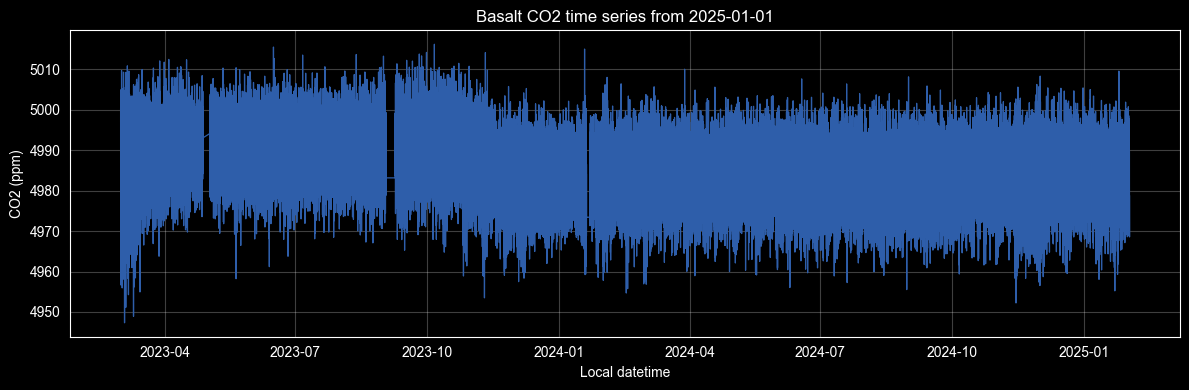

In [11]:
series = series.mask(series < 0)
figure, axis = sensor.plot(series=series.loc["2023-03-01":"2025-02-01"], title="Basalt CO2 time series from 2025-01-01")
# figure, axis = sensor.plot(series=series, title="Basalt CO2 time series")
plt.show()


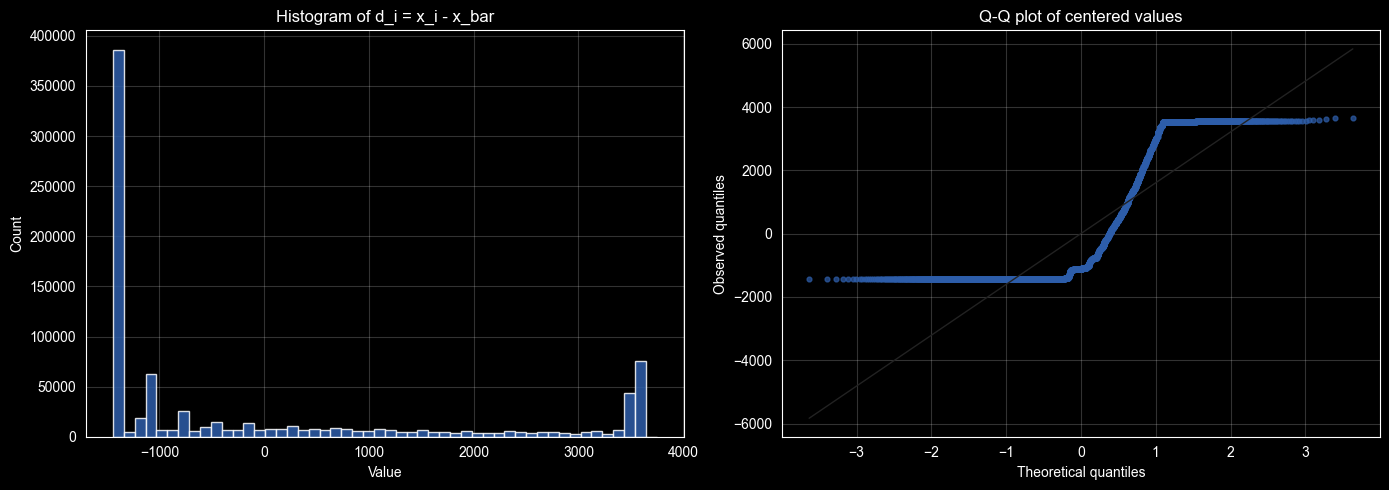

{'sample_size': 883205,
 'excluded_non_finite': 22730,
 'mean': 1.3497352205974973e-13,
 'standard_deviation': 1857.5638967738091,
 'shapiro': {'statistic': 0.7417888008674152,
  'p_value': 6.059172327919418e-185,
  'sample_size': 883205,
  'alpha': 0.05,
  'reject_normality': True,
  'notes': ['scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 883205.']},
 'notes': ['scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 883205.',
  'Excluded 22730 non-finite values before statistical tests.']}

In [12]:
centered = center_series(series)

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_histogram(centered, ax=axes[0], title="Histogram of d_i = x_i - x_bar")
plot_qq(centered, ax=axes[1], title="Q-Q plot of centered values", max_points=5000)
plt.show()

report = normality_report(centered)
display(report.to_dict())
